# 01 — Baselines

**Objetivo.** Establecer el suelo de referencia validado a 252 días. Los baselines solos **no pasan** el umbral (RMSE medio = 88 178 > 75 000) — el cuello de botella son A (231K) y D (239K).

**Decisión tomada.** Baselines antes que cualquier NN. B, C, E, F están bien resueltos por baselines (RMSE 1K–32K). Para A y D hay que mejorar.

**Qué hace.** `eval_all_baselines` para los 6 índices → tabla de RMSE (flat/drift/random_walk). Guarda `results/baselines.json`.

**Qué NO hace.** No entrena redes. No usa datos auxiliares. No escribe ningún `results/index_X.json` — cada notebook de índice (03-08) es el único responsable de escribir su propio JSON.

**Inputs.** `data/train_indices.csv`

**Output esperado.** `results/baselines.json` — dict `{índice: {flat: RMSE, drift: RMSE, random_walk: RMSE}}`.

## 0. GPU workaround + imports

In [1]:
import os
os.environ["CUDA_VISIBLE_DEVICES"] = "-1"

import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from utils import (
    load_hackathon_data, eval_all_baselines,
    backtest_autoregressive, baseline_flat, baseline_drift, baseline_random_walk,
    plot_rollout, plot_rmse_by_index,
    DATA_DIR, VAL_DAYS, V_IN_SHARED, INDEX_COLS
)

## 1. Carga de datos

In [2]:
data = load_hackathon_data(DATA_DIR)
idx  = data['train_indices']

  [OK] train_indices.csv                   11956 filas x 6 cols  (1985-06-24 -> 2028-12-12)


C:\Users\oscar\AppData\Local\Temp\ipykernel_12368\2073274286.py:1: UserWarning: [load_hackathon_data] No encontrado: data/test_dates.csv
  data = load_hackathon_data(DATA_DIR)


  [OK] train_news.csv                      57393 filas x 3 cols  (1986-05-17 -> 2012-02-28)
  [OK] test_news.csv                        1205 filas x 3 cols  (2029-07-30 -> 2029-04-21)
  [OK] train_macro_factors.csv             10905 filas x 3 cols  (1985-06-24 -> 2028-12-12)
  [OK] test_macro_factors.csv                173 filas x 3 cols  (2028-12-13 -> 2029-08-21)
  [OK] train_network_metrics.csv           11956 filas x 2 cols  (1985-06-24 -> 2028-12-12)
  [OK] test_network_metrics.csv              252 filas x 2 cols  (2028-12-13 -> 2029-08-21)


## 2. Backtest de los 3 baselines para los 6 índices

`eval_all_baselines` ejecuta flat/drift/random_walk con `backtest_autoregressive` internamente. El resultado es un DataFrame con RMSE por índice y baseline, ordenado de mejor a peor RMSE medio.

In [3]:
df_baselines = eval_all_baselines(data, val_days=VAL_DAYS, v_in=V_IN_SHARED)
print(df_baselines.round(0))

               Index_A   Index_B  Index_C    Index_D  Index_E  Index_F  \
flat          231143.0   31852.0   8805.0   238599.0  16743.0   1926.0   
random_walk   764858.0  118916.0   9756.0   791715.0  53768.0   4524.0   
drift        1024523.0   49168.0  90421.0  1277318.0   8026.0   1171.0   

             mean_rmse  
flat           88178.0  
random_walk   290589.0  
drift         408438.0  


## 3. Visualización: RMSE por índice y baseline

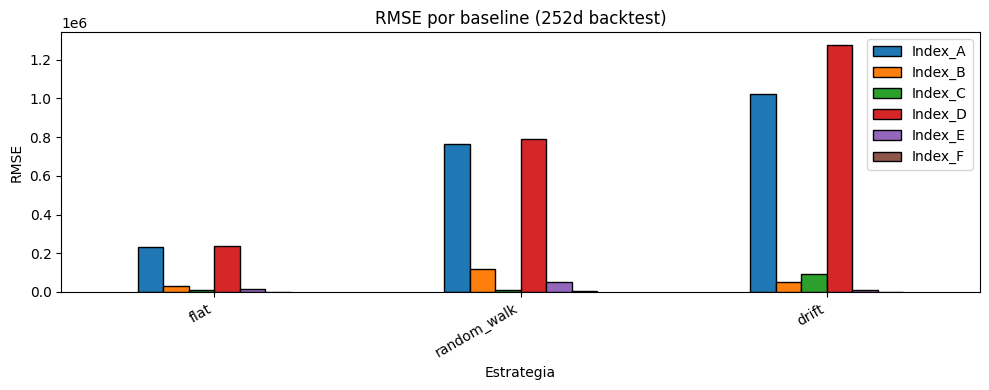

In [4]:
# Tabla en formato dict para plot_rmse_by_index
rmse_dict = {
    baseline: {col: df_baselines.loc[baseline, col]
               for col in INDEX_COLS if col in df_baselines.columns}
    for baseline in df_baselines.index
}
plot_rmse_by_index(rmse_dict, title='RMSE por baseline (252d backtest)')

## 4. Rollout visual del mejor baseline por índice

Para cada índice: identificar el baseline ganador y graficar su rollout vs precios reales.

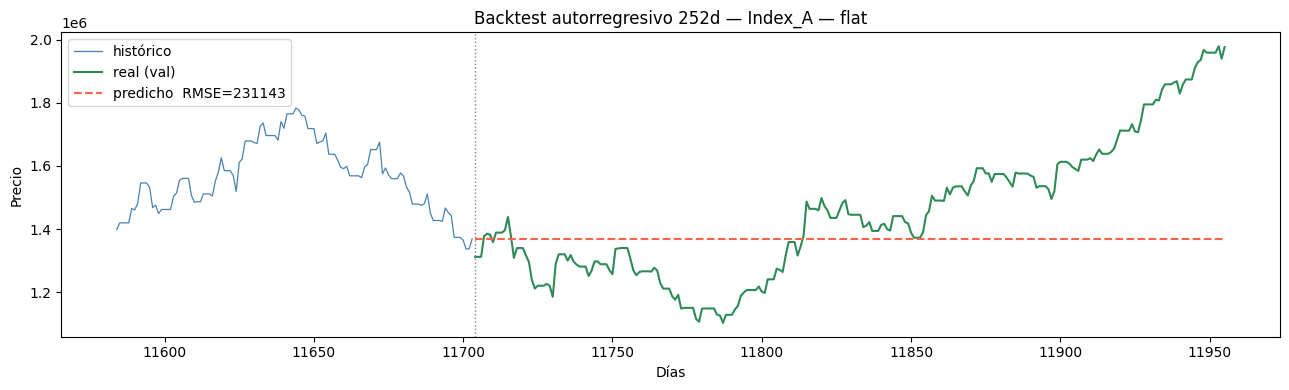

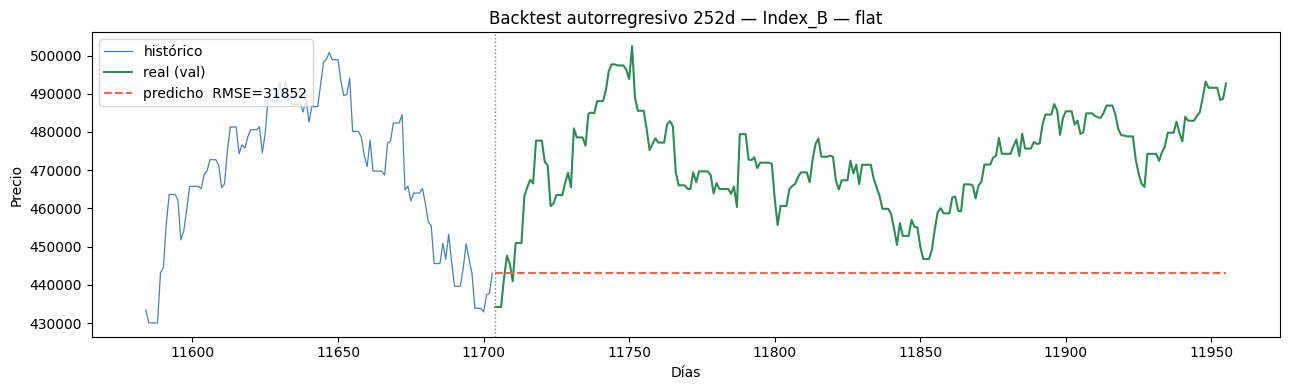

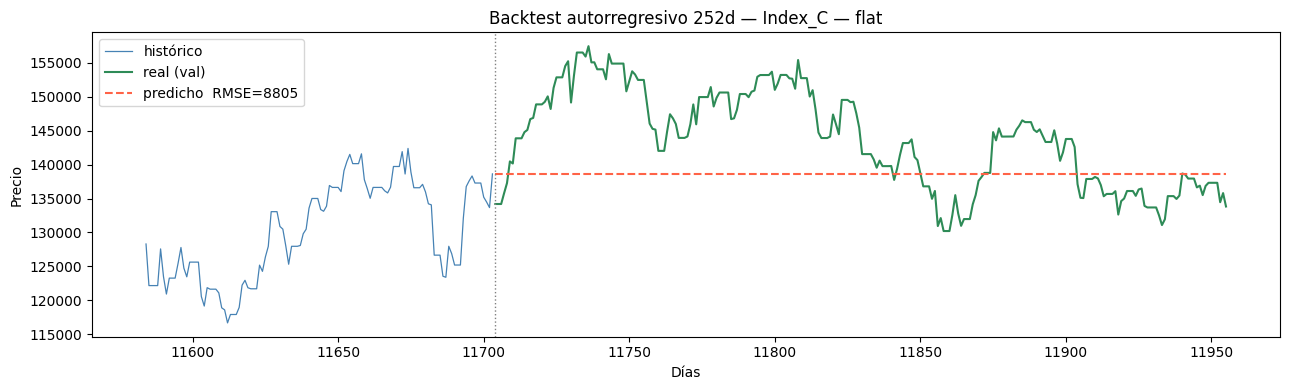

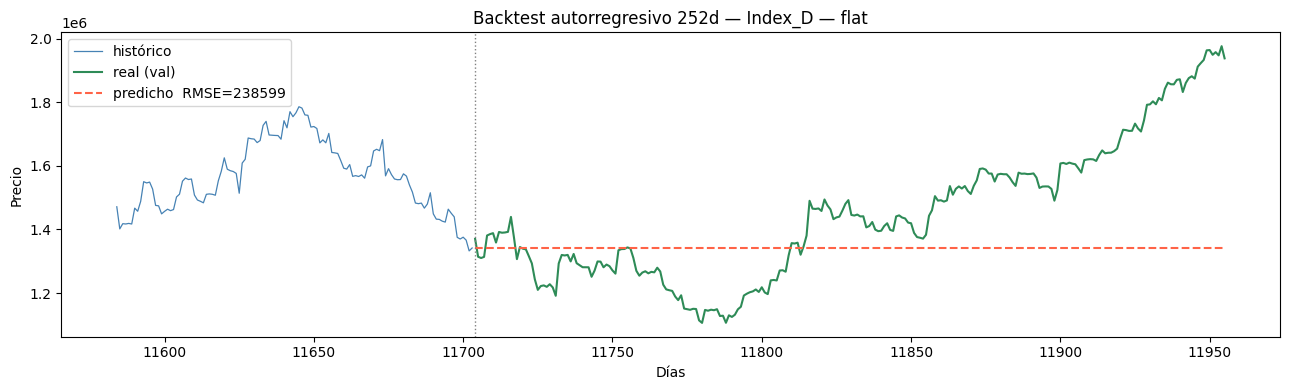

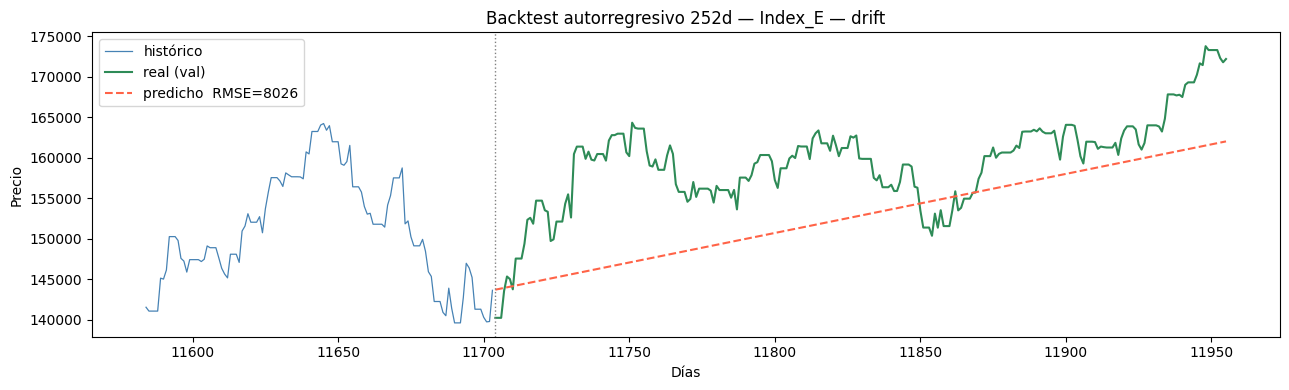

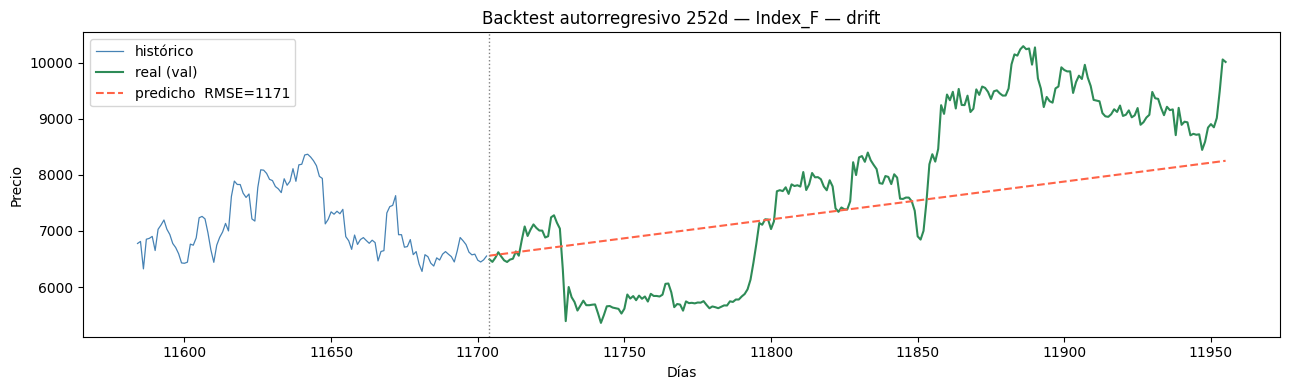

In [5]:
# Para cada índice: correr el mejor baseline manualmente y graficar
for col in INDEX_COLS:
    if col not in idx.columns:
        continue
    serie = idx[col].dropna().values
    n_train = len(serie) - VAL_DAYS
    train_s = serie[:n_train]

    # Mejor baseline según df_baselines
    best_bl = df_baselines[col].idxmin()   # nombre del baseline con menor RMSE

    if best_bl == 'flat':
        preds = baseline_flat(train_s, VAL_DAYS)
    elif best_bl == 'drift':
        preds = baseline_drift(train_s, VAL_DAYS)
    else:
        preds = baseline_random_walk(train_s, VAL_DAYS)

    plot_rollout(serie, preds, index_name=f'{col} — {best_bl}', val_days=VAL_DAYS)

## 5. Decisión y guardado de baselines.json

**REGLA:** Este notebook escribe SOLO `results/baselines.json`. Cada `results/index_X.json` lo escribe EXCLUSIVAMENTE el notebook de ese índice (03-08), incluso si el approach ganador es un baseline.

In [6]:
# Construir dict {índice: {flat: RMSE, drift: RMSE, random_walk: RMSE}}
baselines_out = {}
for col in INDEX_COLS:
    if col in df_baselines.columns:
        baselines_out[col] = {
            'flat':        float(df_baselines.loc['flat',        col]),
            'drift':       float(df_baselines.loc['drift',       col]),
            'random_walk': float(df_baselines.loc['random_walk', col]),
        }

os.makedirs('results', exist_ok=True)
with open('results/baselines.json', 'w') as f:
    json.dump(baselines_out, f, indent=2)

print('Guardado: results/baselines.json')
print(json.dumps(baselines_out, indent=2))

Guardado: results/baselines.json
{
  "Index_A": {
    "flat": 231142.6587200623,
    "drift": 1024522.7269004205,
    "random_walk": 764857.6318036662
  },
  "Index_B": {
    "flat": 31851.915701077196,
    "drift": 49168.40054642036,
    "random_walk": 118915.61459590233
  },
  "Index_C": {
    "flat": 8804.679666403612,
    "drift": 90420.75097370164,
    "random_walk": 9755.576280658674
  },
  "Index_D": {
    "flat": 238598.98896854595,
    "drift": 1277317.8971705376,
    "random_walk": 791714.574715651
  },
  "Index_E": {
    "flat": 16743.39227342532,
    "drift": 8026.189843942905,
    "random_walk": 53767.82263932242
  },
  "Index_F": {
    "flat": 1925.6222304194841,
    "drift": 1170.7621173503157,
    "random_walk": 4524.18289531275
  }
}


## 6. Resumen ✓

| Índice | Mejor baseline | RMSE | Notas |
|--------|---------------|------|-------|
| **A** | flat | **231 143** | Drift catastrófico (1 024 523) — serie con tendencia creciente fuerte |
| **B** | flat | **31 852** | Bien resuelto — serie defensiva de baja vol |
| **C** | flat | **8 805** | Sorprendentemente bajo — C casi no se mueve en 252 días |
| **D** | flat | **238 599** | Igual que A (esperado: D ≈ A lag 1). Drift catastrófico (1 277 318) |
| **E** | drift | **8 026** | Drift gana a flat (16 743) — serie con tendencia lineal suave |
| **F** | drift | **1 171** | Muy bajo en absoluto (escala 22.9K). Flat también bueno (1 926) |

**RMSE medio — mejor baseline por índice:** (231 143 + 31 852 + 8 805 + 238 599 + 8 026 + 1 171) / 6 = **86 599**
**RMSE medio — todo flat:** **88 178**
**Umbral de aprobado:** 75 000 → los baselines solos **NO pasan** ✗

---

**¿Qué hace falta para pasar?**

El problema son solo A y D. Con baselines en B/C/E/F (suma = 49 854), para que la media de los 6 sea < 75 000:
> A + D < 75 000 × 6 − 49 854 = **400 146**

- Con **Ghost(D, lag=1)**: si D baja a ~0, A puede quedarse en 231 143 y aún pasamos (231 143 < 400 146). ✓
- Con Ghost(D) + LSTM(A): margen amplio para competir en el ranking.

**Prioridades de esfuerzo confirmadas:**
1. **D — Ghost (crítico):** sólo necesita bajar de ~169K para garantizar el aprobado con baselines en el resto.
2. **A — LSTM + ensemble (ranking):** de 231K hacia abajo, cuanto más, mejor.
3. **C — cuidado con el bar bajo:** flat = 8 805. El LSTM+macro debe batirlo, pero no está garantizado.
4. **E, F, B — baselines probablemente suficientes:** ya en niveles muy buenos.